In [15]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [16]:
# NEW CELL FOR ENV VARS AND SHORT ID

import os

START = os.getenv('START', '2025-01-01')
END = os.getenv('END', '2025-01-30')

import uuid

short_uuid = uuid.uuid4().hex[:6]

In [17]:
# CAN DELETE CELL

# starttime = '2025-04-01'
# endtime = '2025-06-30'

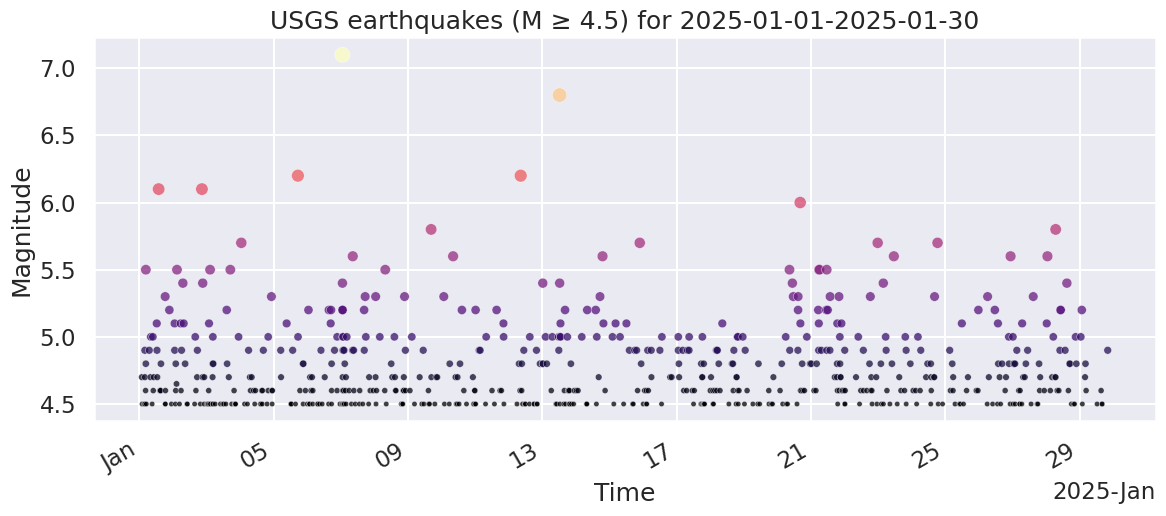

In [18]:
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {"format": "csv", "starttime": START, "endtime": END, "minmagnitude": 4.5}
df = pd.read_csv(url + "?" + "&".join(f"{k}={v}" for k, v in params.items()),
                 parse_dates=["time"])

df = df.sort_values("time")

sns.set_theme(style="darkgrid", context="talk", palette="deep")
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.scatterplot(
    data=df,
    x="time",
    y="mag",
    hue="mag",
    palette="magma",
    size="mag",
    sizes=(15, 120),
    alpha=0.75,
    edgecolor="white",
    linewidth=0.35,
    legend=False,
    ax=ax,
)
ax.set_xlabel("Time")
ax.set_ylabel("Magnitude")
ax.set_title(f"USGS earthquakes (M ≥ 4.5) for {START}-{END}")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate()
plt.tight_layout()


# UPDATE NAMING CONVENTION TO USE VAR

img_name = f"plot-{START}--{END}-{short_uuid}.png"
# fig.savefig(f"plot-{START}--{END}-{short_uuid}.png", dpi=150)
fig.savefig(img_name, dpi=150)
# plt.show()

In [19]:
# NEW CELL FOR UPLOAD(S)

import boto3
from botocore.exceptions import ClientError
import os

s3 = boto3.client(
    's3',
    aws_access_key_id = os.environ.get("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key = os.environ.get("AWS_SECRET_ACCESS_KEY"),
    region_name = 'us-east-1'
)

bucket = "uvasds-data"
UVAID = "nem2p"
key = UVAID + "/" + img_name

try:
    s3.upload_file(img_name, bucket, key)
    print("Upload Successful")
except ClientError as e:
    print(e)

Upload Successful
